In [29]:
import pandas as pd

In [30]:
data=pd.read_csv('/content/synthetic_fraud_dataset.csv')
data.head()

,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Timestamp,Account_Balance,Device_Type,Location,Merchant_Category,IP_Address_Flag,...,Daily_Transaction_Count,Avg_Transaction_Amount_7d,Failed_Transaction_Count_7d,Card_Type,Card_Age,Transaction_Distance,Authentication_Method,Risk_Score,Is_Weekend,Fraud_Label
0,TXN_33553,USER_1834,39.79,POS,2023-08-14 19:30:00,93213.17,Laptop,Sydney,Travel,0,...,7,437.63,3,Amex,65,883.17,Biometric,0.8494,0,0
1,TXN_9427,USER_7875,1.19,Bank Transfer,2023-06-07 04:01:00,75725.25,Mobile,New York,Clothing,0,...,13,478.76,4,Mastercard,186,2203.36,Password,0.0959,0,1
2,TXN_199,USER_2734,28.96,Online,2023-06-20 15:25:00,1588.96,Tablet,Mumbai,Restaurants,0,...,14,50.01,4,Visa,226,1909.29,Biometric,0.8400,0,1
3,TXN_12447,USER_2617,254.32,ATM Withdrawal,2023-12-07 00:31:00,76807.20,Tablet,New York,Clothing,0,...,8,182.48,4,Visa,76,1311.86,OTP,0.7935,0,1
4,TXN_39489,USER_2014,31.28,POS,2023-11-11 23:44:00,92354.66,Mobile,Mumbai,Electronics,0,...,14,328.69,4,Mastercard,140,966.98,Password,0.3819,1,1


In [31]:
data = data.drop(['Transaction_ID', 'User_ID', 'Timestamp', 'Location'], axis=1)
display(data.head())

,Transaction_Amount,Transaction_Type,Account_Balance,Device_Type,Merchant_Category,IP_Address_Flag,Previous_Fraudulent_Activity,Daily_Transaction_Count,Avg_Transaction_Amount_7d,Failed_Transaction_Count_7d,Card_Type,Card_Age,Transaction_Distance,Authentication_Method,Risk_Score,Is_Weekend,Fraud_Label
0,39.79,POS,93213.17,Laptop,Travel,0,0,7,437.63,3,Amex,65,883.17,Biometric,0.8494,0,0
1,1.19,Bank Transfer,75725.25,Mobile,Clothing,0,0,13,478.76,4,Mastercard,186,2203.36,Password,0.0959,0,1
2,28.96,Online,1588.96,Tablet,Restaurants,0,0,14,50.01,4,Visa,226,1909.29,Biometric,0.8400,0,1
3,254.32,ATM Withdrawal,76807.20,Tablet,Clothing,0,0,8,182.48,4,Visa,76,1311.86,OTP,0.7935,0,1
4,31.28,POS,92354.66,Mobile,Electronics,0,1,14,328.69,4,Mastercard,140,966.98,Password,0.3819,1,1


In [32]:
display(data.duplicated().sum())

np.int64(0)

In [33]:
display(data.isnull().sum())

,0
Transaction_Amount,0
Transaction_Type,0
Account_Balance,0
Device_Type,0
Merchant_Category,0
IP_Address_Flag,0
Previous_Fraudulent_Activity,0
Daily_Transaction_Count,0
Avg_Transaction_Amount_7d,0
Failed_Transaction_Count_7d,0


In [34]:
from sklearn.preprocessing import LabelEncoder

categorical_cols = ['Transaction_Type', 'Device_Type', 'Merchant_Category', 'Card_Type', 'Authentication_Method']
for col in categorical_cols:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])

display(data.head())

,Transaction_Amount,Transaction_Type,Account_Balance,Device_Type,Merchant_Category,IP_Address_Flag,Previous_Fraudulent_Activity,Daily_Transaction_Count,Avg_Transaction_Amount_7d,Failed_Transaction_Count_7d,Card_Type,Card_Age,Transaction_Distance,Authentication_Method,Risk_Score,Is_Weekend,Fraud_Label
0,39.79,3,93213.17,0,4,0,0,7,437.63,3,0,65,883.17,0,0.8494,0,0
1,1.19,1,75725.25,1,0,0,0,13,478.76,4,2,186,2203.36,3,0.0959,0,1
2,28.96,2,1588.96,2,3,0,0,14,50.01,4,3,226,1909.29,0,0.8400,0,1
3,254.32,0,76807.20,2,0,0,0,8,182.48,4,3,76,1311.86,1,0.7935,0,1
4,31.28,3,92354.66,1,1,0,1,14,328.69,4,2,140,966.98,3,0.3819,1,1


(50000, 16)

(50000,)

In [37]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Transaction_Amount            50000 non-null  float64
 1   Transaction_Type              50000 non-null  int64  
 2   Account_Balance               50000 non-null  float64
 3   Device_Type                   50000 non-null  int64  
 4   Merchant_Category             50000 non-null  int64  
 5   IP_Address_Flag               50000 non-null  int64  
 6   Previous_Fraudulent_Activity  50000 non-null  int64  
 7   Daily_Transaction_Count       50000 non-null  int64  
 8   Avg_Transaction_Amount_7d     50000 non-null  float64
 9   Failed_Transaction_Count_7d   50000 non-null  int64  
 10  Card_Type                     50000 non-null  int64  
 11  Card_Age                      50000 non-null  int64  
 12  Transaction_Distance          50000 non-null  float64
 13  A

In [38]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

display(X_train.shape)
display(X_test.shape)
display(y_train.shape)
display(y_test.shape)

(40000, 16)

(10000, 16)

(40000,)

(10000,)

In [39]:
import statsmodels.api as sm

# Add a constant to the independent variables
X_train_sm = sm.add_constant(X_train)

# Fit the logistic regression model
model = sm.Logit(y_train, X_train_sm)
result = model.fit()

# Display the summary of the model
display(result.summary())

Optimization terminated successfully.
         Current function value: 0.365017
         Iterations 7


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:            Fraud_Label   No. Observations:                40000
Model:                          Logit   Df Residuals:                    39983
Method:                           MLE   Df Model:                           16
Date:                Mon, 22 Sep 2025   Pseudo R-squ.:                  0.4183
Time:                        10:06:06   Log-Likelihood:                -14601.
converged:                       True   LL-Null:                       -25099.
Covariance Type:            nonrobust   LLR p-value:                     0.000
================================================================================================
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
const                           -6.7098      0.101    -66.286      0.000      -6.908      -6.511
Transaction_Amount           -4.474e-05      0.000     -0.302      0.763      -0.000       0.000
Transaction_Type                -0.0132      0.013     -1.007      0.314      -0.039       0.012
Account_Balance               5.727e-09    5.1e-07      0.011      0.991   -9.94e-07    1.01e-06
Device_Type                      0.0018      0.018      0.100      0.920      -0.033       0.037
Merchant_Category                0.0106      0.010      1.020      0.308      -0.010       0.031
IP_Address_Flag                  0.0184      0.066      0.278      0.781      -0.111       0.148
Previous_Fraudulent_Activity     0.0048      0.050      0.097      0.923      -0.092       0.102
Daily_Transaction_Count         -0.0012      0.004     -0.328      0.743      -0.008       0.006
Avg_Transaction_Amount_7d    -8.425e-05      0.000     -0.810      0.418      -0.000       0.000
Failed_Transaction_Count_7d      1.3332      0.015     90.907      0.000       1.304       1.362
Card_Type                        0.0019      0.013      0.145      0.884      -0.024       0.028
Card_Age                     -4.242e-05      0.000     -0.200      0.842      -0.000       0.000
Transaction_Distance          8.073e-06   1.02e-05      0.795      0.427   -1.18e-05     2.8e-05
Authentication_Method           -0.0075      0.013     -0.572      0.568      -0.033       0.018
Risk_Score                       5.2121      0.066     79.388      0.000       5.083       5.341
Is_Weekend                       0.0373      0.032      1.164      0.244      -0.025       0.100
================================================================================================
"""

In [41]:
from sklearn.metrics import confusion_matrix, roc_auc_score, precision_score, recall_score, f1_score
import numpy as np

# Add a constant to the test data
X_test_sm = sm.add_constant(X_test, has_constant='add')

# Get predicted probabilities
y_pred_prob = result.predict(X_test_sm)

# Convert probabilities to binary predictions using a threshold (e.g., 0.5)
y_pred = (y_pred_prob > 0.5).astype(int)

# Calculate evaluation metrics
conf_matrix = confusion_matrix(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_prob)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Display the metrics
display("Confusion Matrix:")
display(conf_matrix)
display("AUC:")
display(auc)
display("Precision:")
display(precision)
display("Recall:")
display(recall)
display("F1 Score:")
display(f1)

'Confusion Matrix:'

array([[5929,  836],
       [1181, 2054]])

'AUC:'

np.float64(0.8938987492446232)

'Precision:'

0.7107266435986159

'Recall:'

0.6349304482225657

'F1 Score:'

0.6706938775510204

In [43]:
display(data['Fraud_Label'].value_counts())

,count
Fraud_Label,
0,33933
1,16067


In [44]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

display("Shape of X_train before SMOTE:")
display(X_train.shape)
display("Shape of X_train after SMOTE:")
display(X_train_resampled.shape)
display("Value counts of y_train before SMOTE:")
display(y_train.value_counts())
display("Value counts of y_train after SMOTE:")
display(y_train_resampled.value_counts())

'Shape of X_train before SMOTE:'

(40000, 16)

'Shape of X_train after SMOTE:'

(54336, 16)

'Value counts of y_train before SMOTE:'

,count
Fraud_Label,
0,27168
1,12832


'Value counts of y_train after SMOTE:'

,count
Fraud_Label,
1,27168
0,27168


In [45]:
import statsmodels.api as sm

# Add a constant to the resampled independent variables
X_train_resampled_sm = sm.add_constant(X_train_resampled)

# Fit the logistic regression model on the resampled data
model_resampled = sm.Logit(y_train_resampled, X_train_resampled_sm)
result_resampled = model_resampled.fit()

# Display the summary of the model
display(result_resampled.summary())

Optimization terminated successfully.
         Current function value: 0.388031
         Iterations 7


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:            Fraud_Label   No. Observations:                54336
Model:                          Logit   Df Residuals:                    54319
Method:                           MLE   Df Model:                           16
Date:                Mon, 22 Sep 2025   Pseudo R-squ.:                  0.4402
Time:                        10:16:32   Log-Likelihood:                -21084.
converged:                       True   LL-Null:                       -37663.
Covariance Type:            nonrobust   LLR p-value:                     0.000
================================================================================================
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
const                           -4.5742      0.080    -56.845      0.000      -4.732      -4.416
Transaction_Amount              -0.0004      0.000     -2.721      0.007      -0.001   -9.86e-05
Transaction_Type                -0.1832      0.011    -16.140      0.000      -0.205      -0.161
Account_Balance               4.074e-07   4.23e-07      0.963      0.336   -4.22e-07    1.24e-06
Device_Type                     -0.2665      0.015    -17.294      0.000      -0.297      -0.236
Merchant_Category               -0.1073      0.009    -11.908      0.000      -0.125      -0.090
IP_Address_Flag                 -0.6700      0.066    -10.143      0.000      -0.799      -0.541
Previous_Fraudulent_Activity    -0.6604      0.048    -13.764      0.000      -0.754      -0.566
Daily_Transaction_Count         -0.0200      0.003     -6.282      0.000      -0.026      -0.014
Avg_Transaction_Amount_7d    -4.666e-05   8.92e-05     -0.523      0.601      -0.000       0.000
Failed_Transaction_Count_7d      1.3039      0.012    107.784      0.000       1.280       1.328
Card_Type                       -0.1660      0.011    -14.583      0.000      -0.188      -0.144
Card_Age                        -0.0002      0.000     -1.313      0.189      -0.001       0.000
Transaction_Distance          8.386e-06   8.41e-06      0.997      0.319    -8.1e-06    2.49e-05
Authentication_Method           -0.1724      0.011    -15.171      0.000      -0.195      -0.150
Risk_Score                       5.7772      0.058     99.585      0.000       5.663       5.891
Is_Weekend                      -0.5374      0.029    -18.769      0.000      -0.593      -0.481
================================================================================================
"""

Let's implement a basic forward stepwise selection for logistic regression using `statsmodels`. This process will start with no features and iteratively add the feature that most improves the model, based on its p-value, until no remaining feature has a p-value below a certain threshold (commonly 0.05).

In [46]:
import statsmodels.api as sm

def forward_stepwise_selection(X, y, initial_list=[], threshold_in=0.05):
    """
    Performs forward stepwise logistic regression.

    Parameters:
    -----------
    X : pandas.DataFrame
        The independent variables.
    y : pandas.Series or numpy.ndarray
        The dependent variable.
    initial_list : list, optional
        Initial list of features to start with. Defaults to an empty list.
    threshold_in : float, optional
        The p-value threshold for adding a feature. Defaults to 0.05.

    Returns:
    --------
    list
        The selected features.
    """
    included = list(initial_list)
    while True:
        changed = False
        # forward step
        excluded = list(set(X.columns) - set(included))
        new_pval = pd.Series(index=excluded)
        for new_column in excluded:
            model = sm.Logit(y, sm.add_constant(X[included + [new_column]]))
            result = model.fit(disp=0) # disp=0 to suppress convergence output
            new_pval[new_column] = result.pvalues[new_column]
        best_pval = new_pval.min()
        if best_pval < threshold_in:
            best_feature = new_pval.idxmin()
            included.append(best_feature)
            changed = True
            print(f'Add {best_feature} with p-value {best_pval:.4f}')

        if not changed:
            break
    return included

# Perform forward stepwise selection on the resampled training data
selected_features = forward_stepwise_selection(X_train_resampled, y_train_resampled)

display("Selected features through stepwise regression:")
display(selected_features)

Add Risk_Score with p-value 0.0000
Add Failed_Transaction_Count_7d with p-value 0.0000
Add Is_Weekend with p-value 0.0000
Add Device_Type with p-value 0.0000
Add Transaction_Type with p-value 0.0000
Add Authentication_Method with p-value 0.0000
Add Card_Type with p-value 0.0000
Add Previous_Fraudulent_Activity with p-value 0.0000
Add Merchant_Category with p-value 0.0000
Add IP_Address_Flag with p-value 0.0000
Add Daily_Transaction_Count with p-value 0.0000
Add Transaction_Amount with p-value 0.0067


'Selected features through stepwise regression:'

['Risk_Score',
 'Failed_Transaction_Count_7d',
 'Is_Weekend',
 'Device_Type',
 'Transaction_Type',
 'Authentication_Method',
 'Card_Type',
 'Previous_Fraudulent_Activity',
 'Merchant_Category',
 'IP_Address_Flag',
 'Daily_Transaction_Count',
 'Transaction_Amount']

Now that we have the selected features, we can train the logistic regression model using only these features and then evaluate its performance.

In [47]:
# Train the logistic regression model with selected features
X_train_selected = X_train_resampled[selected_features]
X_train_selected_sm = sm.add_constant(X_train_selected)

model_selected = sm.Logit(y_train_resampled, X_train_selected_sm)
result_selected = model_selected.fit()

# Display the summary of the model with selected features
display(result_selected.summary())

Optimization terminated successfully.
         Current function value: 0.388068
         Iterations 7


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:            Fraud_Label   No. Observations:                54336
Model:                          Logit   Df Residuals:                    54323
Method:                           MLE   Df Model:                           12
Date:                Mon, 22 Sep 2025   Pseudo R-squ.:                  0.4401
Time:                        10:18:11   Log-Likelihood:                -21086.
converged:                       True   LL-Null:                       -37663.
Covariance Type:            nonrobust   LLR p-value:                     0.000
================================================================================================
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
const                           -4.5726      0.067    -68.158      0.000      -4.704      -4.441
Risk_Score                       5.7765      0.058     99.595      0.000       5.663       5.890
Failed_Transaction_Count_7d      1.3038      0.012    107.794      0.000       1.280       1.328
Is_Weekend                      -0.5378      0.029    -18.789      0.000      -0.594      -0.482
Device_Type                     -0.2668      0.015    -17.321      0.000      -0.297      -0.237
Transaction_Type                -0.1831      0.011    -16.132      0.000      -0.205      -0.161
Authentication_Method           -0.1723      0.011    -15.172      0.000      -0.195      -0.150
Card_Type                       -0.1661      0.011    -14.591      0.000      -0.188      -0.144
Previous_Fraudulent_Activity    -0.6600      0.048    -13.758      0.000      -0.754      -0.566
Merchant_Category               -0.1075      0.009    -11.926      0.000      -0.125      -0.090
IP_Address_Flag                 -0.6704      0.066    -10.153      0.000      -0.800      -0.541
Daily_Transaction_Count         -0.0200      0.003     -6.285      0.000      -0.026      -0.014
Transaction_Amount              -0.0004      0.000     -2.710      0.007      -0.001   -9.72e-05
================================================================================================
"""

In [48]:
from sklearn.metrics import confusion_matrix, roc_auc_score, precision_score, recall_score, f1_score
import numpy as np
import statsmodels.api as sm

# Select the features in the test set that were selected during stepwise regression
X_test_selected = X_test[selected_features]

# Add a constant to the selected test data
X_test_selected_sm = sm.add_constant(X_test_selected, has_constant='add')

# Get predicted probabilities
y_pred_prob_selected = result_selected.predict(X_test_selected_sm)

# Convert probabilities to binary predictions using a threshold (e.g., 0.5)
y_pred_selected = (y_pred_prob_selected > 0.5).astype(int)

# Calculate evaluation metrics
conf_matrix_selected = confusion_matrix(y_test, y_pred_selected)
auc_selected = roc_auc_score(y_test, y_pred_prob_selected)
precision_selected = precision_score(y_test, y_pred_selected)
recall_selected = recall_score(y_test, y_pred_selected)
f1_selected = f1_score(y_test, y_pred_selected)

# Display the metrics
display("Confusion Matrix (Selected Features):")
display(conf_matrix_selected)
display("AUC (Selected Features):")
display(auc_selected)
display("Precision (Selected Features):")
display(precision_selected)
display("Recall (Selected Features):")
display(recall_selected)
display("F1 Score (Selected Features):")
display(f1_selected)

'Confusion Matrix (Selected Features):'

array([[5375, 1390],
       [ 758, 2477]])

'AUC (Selected Features):'

np.float64(0.8826205432772328)

'Precision (Selected Features):'

0.6405482286009827

'Recall (Selected Features):'

0.7656877897990726

'F1 Score (Selected Features):'

0.6975499859194593

In [65]:
from sklearn.model_selection import cross_val_score

# Perform cross-validation
# Using the resampled training data and the scikit-learn logistic regression model
# We can specify scoring metrics like 'roc_auc', 'precision', 'recall', 'f1'
# Let's use 'roc_auc' as an example, given the imbalanced nature
cv_scores = cross_val_score(model_sklearn, X_train_resampled, y_train_resampled, cv=5, scoring='roc_auc') # Using 5 folds

display("Cross-validation AUC scores:")
display(cv_scores)
display(f"Mean cross-validation AUC: {cv_scores.mean():.4f}")
display(f"Standard deviation of cross-validation AUC: {cv_scores.std():.4f}")

'Cross-validation AUC scores:'

array([0.88395118, 0.87941011, 0.902148  , 0.91183512, 0.90813626])

'Mean cross-validation AUC: 0.8971'

'Standard deviation of cross-validation AUC: 0.0130'

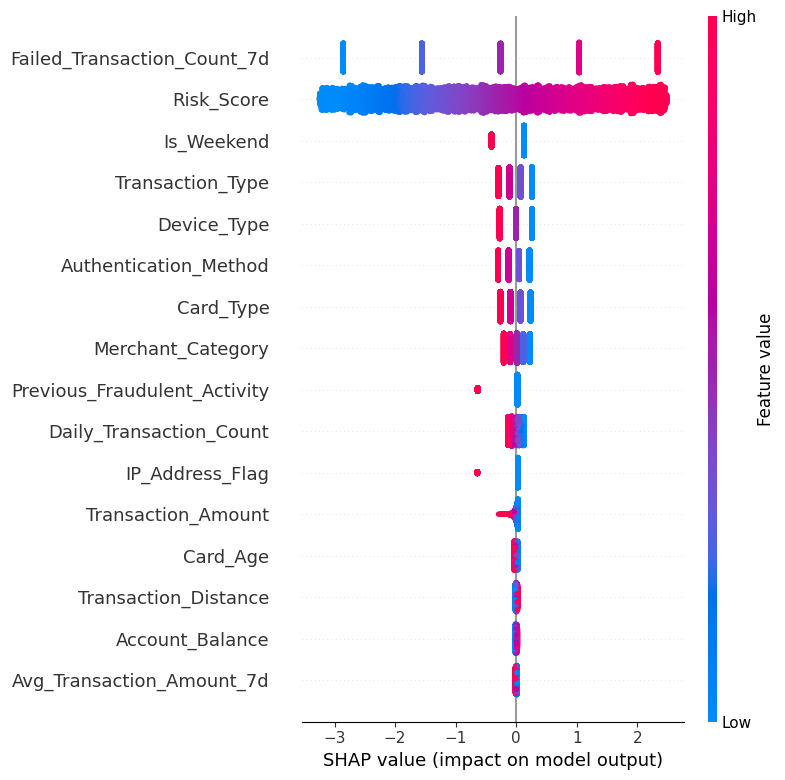

In [64]:
import shap

# Assuming model_sklearn is your trained scikit-learn LogisticRegression model
# And X_test is your test data (without the target variable)

# Create a SHAP LinearExplainer for scikit-learn LogisticRegression
# The explainer needs the trained model and the data
explainer = shap.LinearExplainer(model_sklearn, X_train_resampled) # Use training data for background distribution

# Calculate SHAP values for the test set
# The explainer expects data in the same format as the training data
shap_values = explainer.shap_values(X_test)

# Visualize the summary plot
# Use the original feature names from X_test
shap.summary_plot(shap_values, X_test, feature_names=X_test.columns.tolist())

In [69]:
from sklearn.tree import DecisionTreeClassifier

# Train a Decision Tree Classifier model on the resampled training data with hyperparameters
dt_model = DecisionTreeClassifier(max_depth=6, min_samples_leaf=100, random_state=42)
dt_model.fit(X_train_resampled, y_train_resampled)

display("Decision Tree Classifier model trained with hyperparameters.")

'Decision Tree Classifier model trained with hyperparameters.'

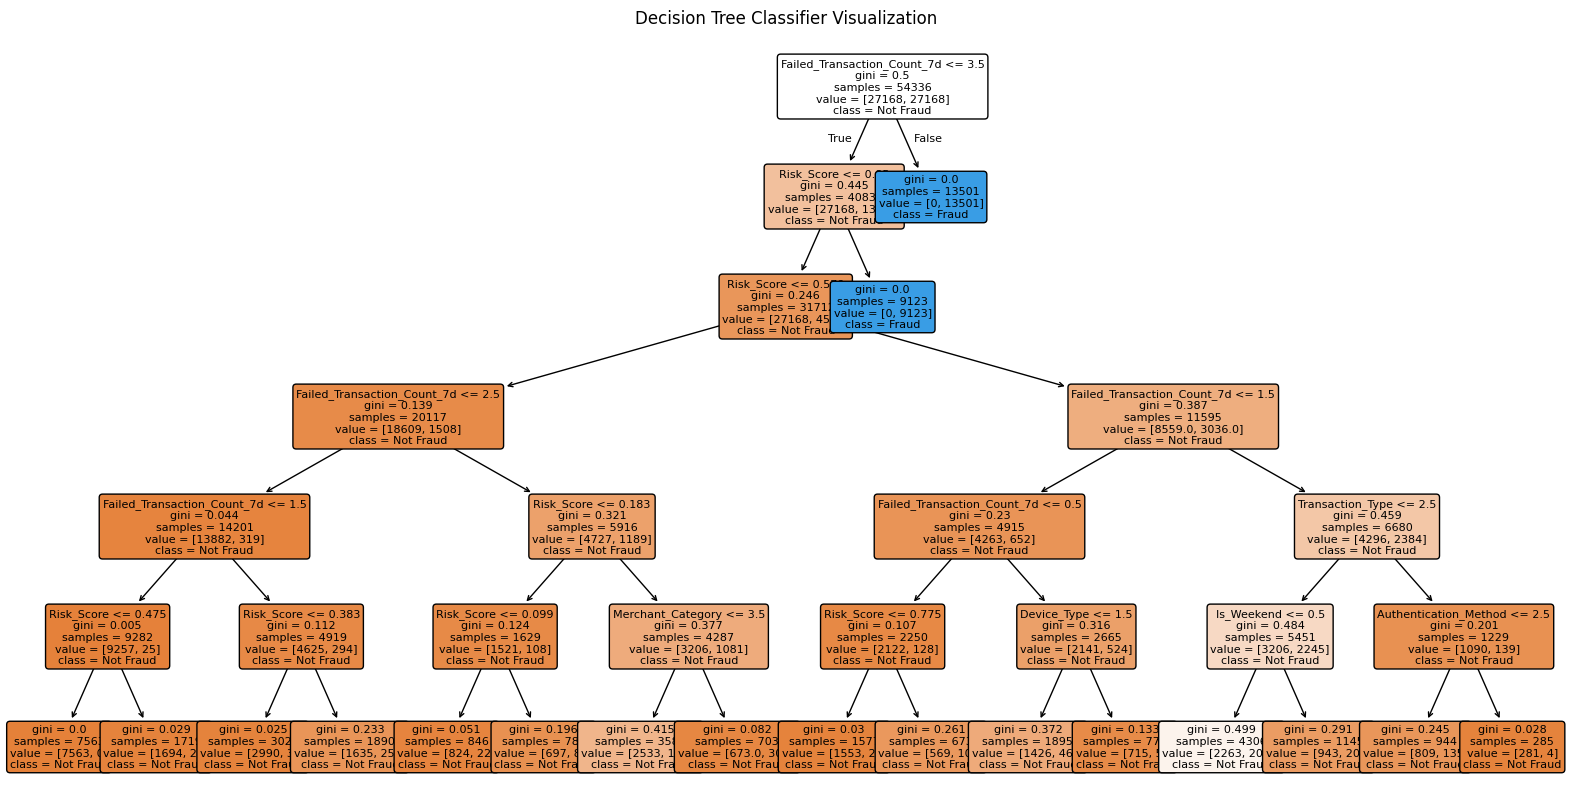

In [70]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Visualize the Decision Tree Classifier
plt.figure(figsize=(20, 10)) # Adjust figure size as needed
plot_tree(dt_model,
          feature_names=X_train_resampled.columns.tolist(),
          class_names=['Not Fraud', 'Fraud'],
          filled=True,
          rounded=True,
          fontsize=8)
plt.title("Decision Tree Classifier Visualization")
plt.show()